In [1]:
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Files already downloaded and verified
Files already downloaded and verified
torch.Size([5, 3, 32, 32]) torch.Size([5])


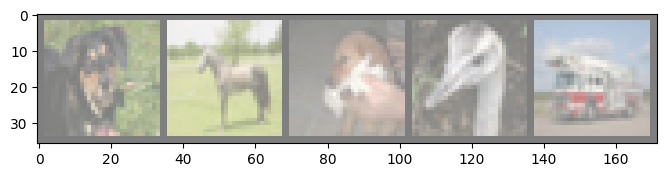

dog horse dog bird truck
epoch 0 step 0 / 10000 loss 2.2466
epoch 1 step 0 / 10000 loss 2.5957
epoch 2 step 0 / 10000 loss 1.6166
epoch 3 step 0 / 10000 loss 1.7767
epoch 4 step 0 / 10000 loss 1.1867
epoch 5 step 0 / 10000 loss 1.0781
epoch 6 step 0 / 10000 loss 1.8465
epoch 7 step 0 / 10000 loss 2.1166
epoch 8 step 0 / 10000 loss 1.7016
epoch 9 step 0 / 10000 loss 1.0772
accuracy 50.730


In [3]:
learning_rate=0.001
batch_size=5

train_dataset=torchvision.datasets.CIFAR10(root='./data',train=True,transform=transforms.ToTensor(),download=True)

test_dataset=torchvision.datasets.CIFAR10(root='./data',train=False,transform=transforms.ToTensor(),download=True)

train_loader=DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True,num_workers=4)
test_loader=DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=False,num_workers=4)

classes=('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

def imshow(img):
    img=img/2+.5 # unnormalize
    npimg=img.numpy()
    plt.figure(figsize=(8,6))
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.show()

examples=iter(train_loader)
samples,labels=next(examples)
print(samples.shape , labels.shape)
imshow(torchvision.utils.make_grid(samples))
print(' '.join(f"{classes[labels[j]]}" for j in range(len(labels))))


class convnet(nn.Module):
    def __init__(self):
        super(convnet,self).__init__()
        self.conv1=nn.Conv2d(3,6,5)
        self.pooling=nn.MaxPool2d(2,2)
        self.conv2=nn.Conv2d(6,16,5)
        self.fc1=nn.Linear(16*5*5,120)
        self.fc2=nn.Linear(120,84)
        self.fc3=nn.Linear(84,10)


    def forward(self,x):
        out=self.pooling(torch.relu(self.conv1(x)))
        out=self.pooling(torch.relu(self.conv2(out)))
        out=out.view(-1,16*5*5)
        out=self.fc3(self.fc2(self.fc1(out)))
        return out
    
model=convnet().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)


# training
num_epochs=10
num_total_steps=len(train_loader)
for epoch in range(num_epochs):
    for i,(images,labels) in enumerate(train_loader):
        images=images.to(device)
        labels=labels.to(images).long()
        # forward pass
        outputs=model(images)
        loss=criterion(outputs,labels)

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 10000 == 0:
            print(f"epoch {epoch} step {i} / {num_total_steps} loss {loss.item():.4f}")

with torch.no_grad():
    num_correct=0
    num_samples=0
    for images,labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)
        _,predictions=torch.max(outputs,1)
        num_correct+=(predictions==labels).sum().item()
        num_samples+=labels.shape[0]

acc=num_correct/num_samples*100
print(f"accuracy {acc:.3f}")



In [4]:
for images,labels in train_loader:
    print(images.shape , labels.shape)
    break

torch.Size([5, 3, 32, 32]) torch.Size([5])
